In [30]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
from torchvision.transforms import transforms
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [32]:
image_path = []
labels = []

for i in os.listdir('data'):
    for label in os.listdir(f'data/{i}'):
        for image in os.listdir(f'data/{i}/{label}'):
            image_path.append(f'data/{i}/{label}/{image}')
            labels.append(label)
            

In [33]:
df = pd.DataFrame({'image_path': image_path, 'labels': labels})

In [34]:
df.head()

,image_path,labels
0,data/train/cat/flickr_cat_000002.jpg,cat
1,data/train/cat/flickr_cat_000003.jpg,cat
2,data/train/cat/flickr_cat_000004.jpg,cat
3,data/train/cat/flickr_cat_000005.jpg,cat
4,data/train/cat/flickr_cat_000006.jpg,cat


In [35]:
train = df.sample(frac=0.7, random_state=42)
test = df.drop(train.index)
validation = test.sample(frac=0.5, random_state=42)
test = test.drop(validation.index)


print(f"Train size: {len(train)}")
print(f"Validation size: {len(validation)}")    
print(f"Test size: {len(test)}")

Train size: 11291
Validation size: 2420
Test size: 2419


In [36]:
label_encoder = LabelEncoder()
label_encoder.fit(df['labels'])

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [44]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image).to(device)
        return image, label

In [45]:
train_dataset = CustomImageDataset(train, transform=transform)
val_dataset = CustomImageDataset(validation, transform=transform)
test_dataset = CustomImageDataset(test, transform=transform)

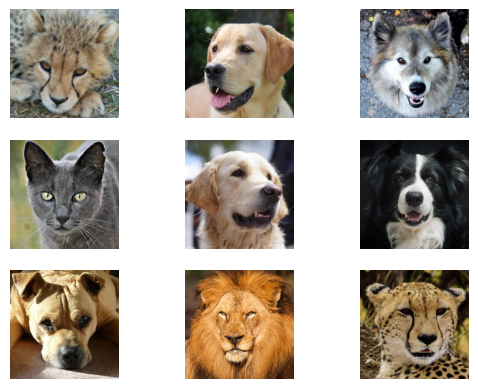

In [46]:
n_rows = 3
n_cols = 3

f,axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col in range(n_cols):
        image = Image.open(df.sample(n=1)['image_path'].iloc[0]).convert("RGB")
        axarr[row, col].imshow(image)
        axarr[row, col].axis('off')
plt.show()

In [47]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [48]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [52]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pooling = nn.MaxPool2d(2,2)
        self.Relu = nn.ReLU()
        self.Flatten = nn.Flatten()
        self.linear = nn.Linear(128*16*16, 128)
        self.output = nn.Linear(128, len(label_encoder.classes_))


    def forward(self, x):
        x = self.conv1(x)
        x = self.pooling(x)
        x = self.Relu(x)

        x = self.conv2(x)
        x = self.pooling(x)
        x = self.Relu(x)

        x = self.conv3(x)
        x = self.pooling(x)
        x = self.Relu(x)

        x = self.Flatten(x)
        x = self.linear(x)
        x = self.output(x)
        return x

In [53]:
model = Net().to(device)

In [54]:
from torchsummary import summary
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [55]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)

In [58]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []


for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()  
        optimizer.step()

        
        _, predicted = torch.max(outputs.data, 1)
        total_acc_train += (predicted == labels).sum().item()


    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_acc_val += (predicted == labels).sum().item()


    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_val/1000, 4))

    total_acc_train_plot.append(round(100 * total_acc_train / len(train_dataset), 4))
    total_acc_validation_plot.append(round(100 * total_acc_val / len(val_dataset), 4))


    print(f'''end=of epoch {epoch+1}/{EPOCHS} |
          Train Loss: {round(total_loss_train/1000, 4)} |   
            Validation Loss: {round(total_loss_val/1000, 4)} |
            Train Accuracy: {round(100 * total_acc_train / len(train_dataset), 4)} |
            Validation Accuracy: {round(100 * total_acc_val / len(val_dataset), 4)}''')
    

end=of epoch 1/10 |
          Train Loss: 0.299 |   
            Validation Loss: 0.0372 |
            Train Accuracy: 83.8633 |
            Validation Accuracy: 91.0331
end=of epoch 2/10 |
          Train Loss: 0.1403 |   
            Validation Loss: 0.028 |
            Train Accuracy: 92.7996 |
            Validation Accuracy: 93.1818
end=of epoch 3/10 |
          Train Loss: 0.087 |   
            Validation Loss: 0.0194 |
            Train Accuracy: 95.6071 |
            Validation Accuracy: 95.0826
end=of epoch 4/10 |
          Train Loss: 0.062 |   
            Validation Loss: 0.0165 |
            Train Accuracy: 96.9622 |
            Validation Accuracy: 96.157
end=of epoch 5/10 |
          Train Loss: 0.0444 |   
            Validation Loss: 0.0179 |
            Train Accuracy: 97.7681 |
            Validation Accuracy: 95.9091
end=of epoch 6/10 |
          Train Loss: 0.0371 |   
            Validation Loss: 0.0148 |
            Train Accuracy: 98.2287 |
            Validati

In [59]:
with torch.no_grad():
    total_acc_test = 0
    total_loss_test = 0

    for inputs, labels in test_loader:
        outputs = model(inputs)
        test_loss = criterion(outputs, labels)
        total_loss_test += test_loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_acc_test += (predicted == labels).sum().item()

    print(f'''Test Loss: {round(total_loss_test/1000, 4)} |
          Test Accuracy: {round(100 * total_acc_test / len(test_dataset), 4)}''')

Test Loss: 0.0191 |
          Test Accuracy: 96.4448


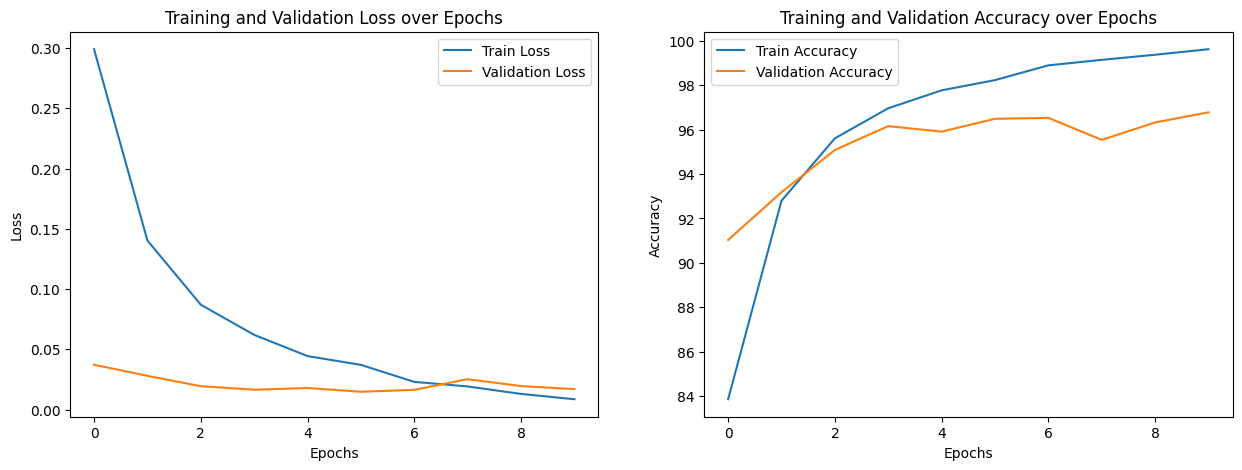

In [60]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Train Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()



axs[1].plot(total_acc_train_plot, label='Train Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [67]:
#1. Read image
#2. Preprocess image using transforms
#3. Predict through the model
#4. inverse transform the label to get the original class name


def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs.data, 1)
        predicted_label = label_encoder.inverse_transform(predicted.cpu().numpy())[0]

    return predicted_label


predict_image('./billa.jpg')

'wild'